# `data/test/` 실사진 전량 평가 (룰베이스 vs Mask R-CNN)

`data/test/`는 README 계획상 **직접 촬영한 진짜 Test 세트**(크롤링이 아니라 실사용 사진) — train(`data/raw2`)과는 다른 도메인이라 domain shift 평가에 해당한다. 정확도가 raw2 기준보다 낮게 나오는 것은 의도된 설계이지 버그가 아니다 (CLAUDE.md 참고).

**주의**: README 원칙은 "Test는 최종 평가 1회만"이다. 아직 ResNet/EfficientNet 트랙이 없어서 이번 실행은 4트랙 최종 평가가 아니라 **현재 2개 트랙(룰베이스, Mask R-CNN)에 대한 중간 점검**이다.

In [1]:
import sys, os, glob, time
from collections import Counter

sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from rule_based.shape_classifier import get_mask, classify_shape, SHAPE_LABELS_KO
from deep_learning.dl1_maskrcnn import load_model, get_mask_maskrcnn

DATA_DIR = os.path.join("..", "data", "test")
CLASSES = ["straight", "taper_smooth", "taper_step", "mug"]


def imread_unicode(path):
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def safe_classify(mask):
    if mask is None or not mask.any():
        return {"shape": "미검출"}
    return classify_shape(mask)


mrcnn_model, device = load_model()
print("device:", device)

test_paths = {}
for cls in CLASSES:
    files = sorted(glob.glob(os.path.join(DATA_DIR, cls, "*.*")))
    test_paths[cls] = [f for f in files if os.path.splitext(f)[1].lower() in (".jpg", ".jpeg", ".png")]
    print(f"{cls}: {len(test_paths[cls])}장")
print(f"합계: {sum(len(v) for v in test_paths.values())}장")

device: cuda
straight: 18장
taper_smooth: 10장
taper_step: 22장
mug: 6장
합계: 56장


## 클래스별 원본 / 룰베이스 마스크 / Mask R-CNN 마스크

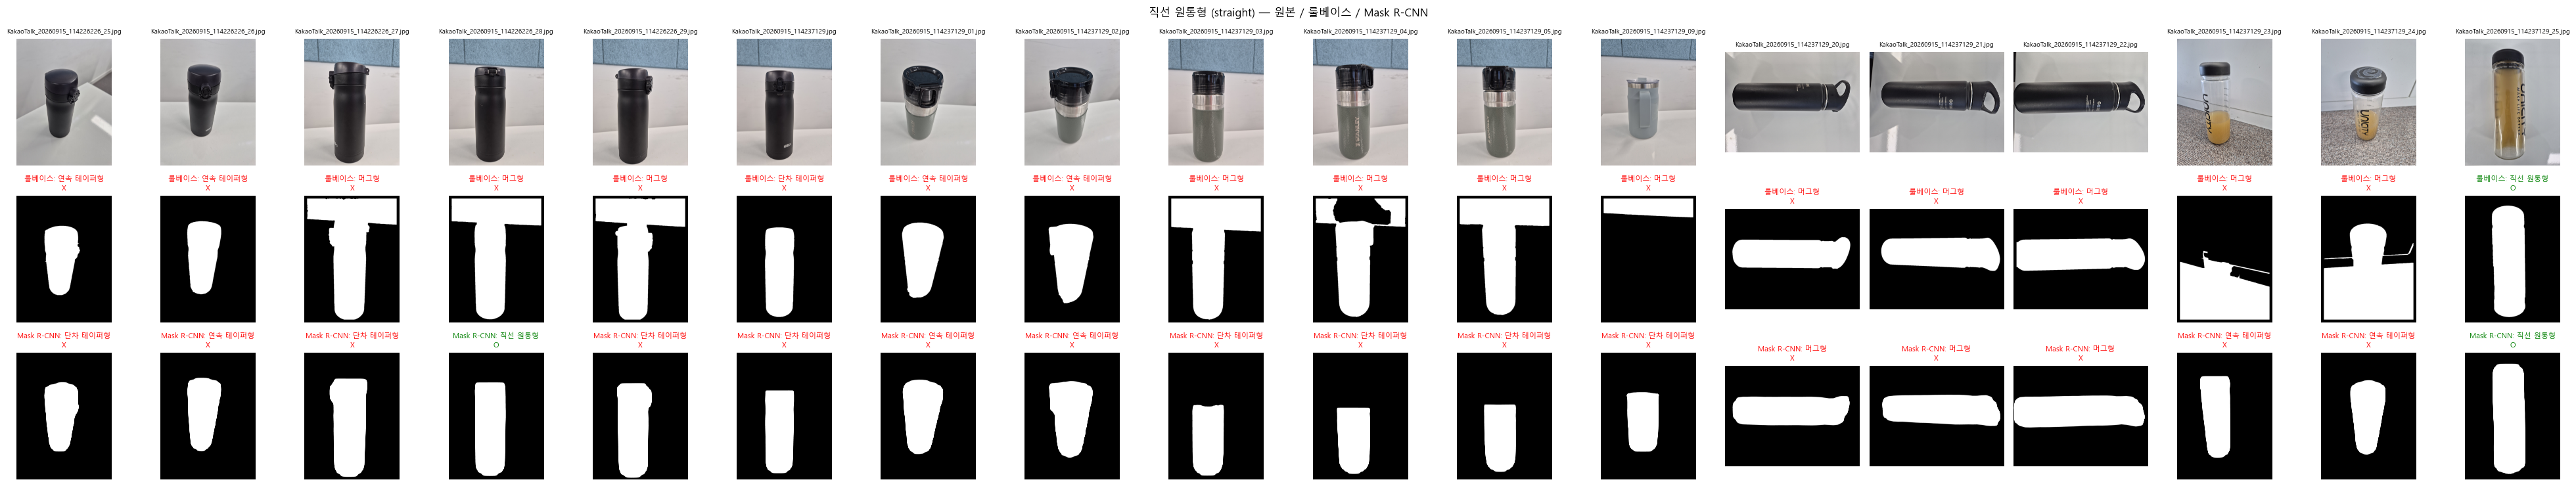

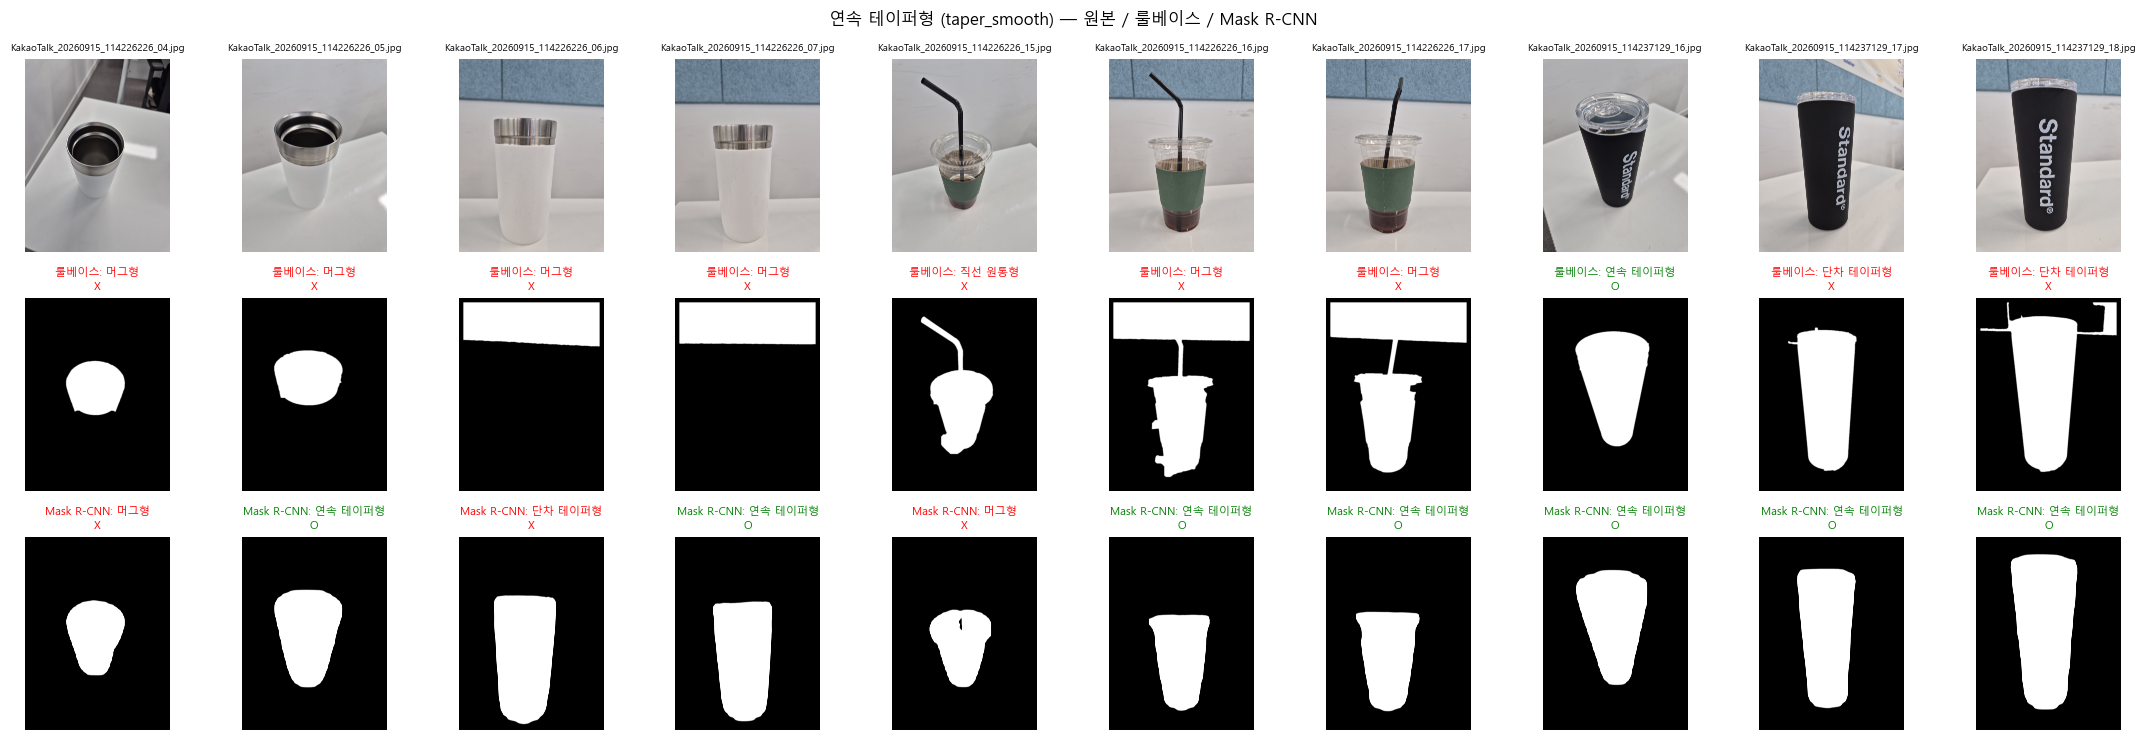

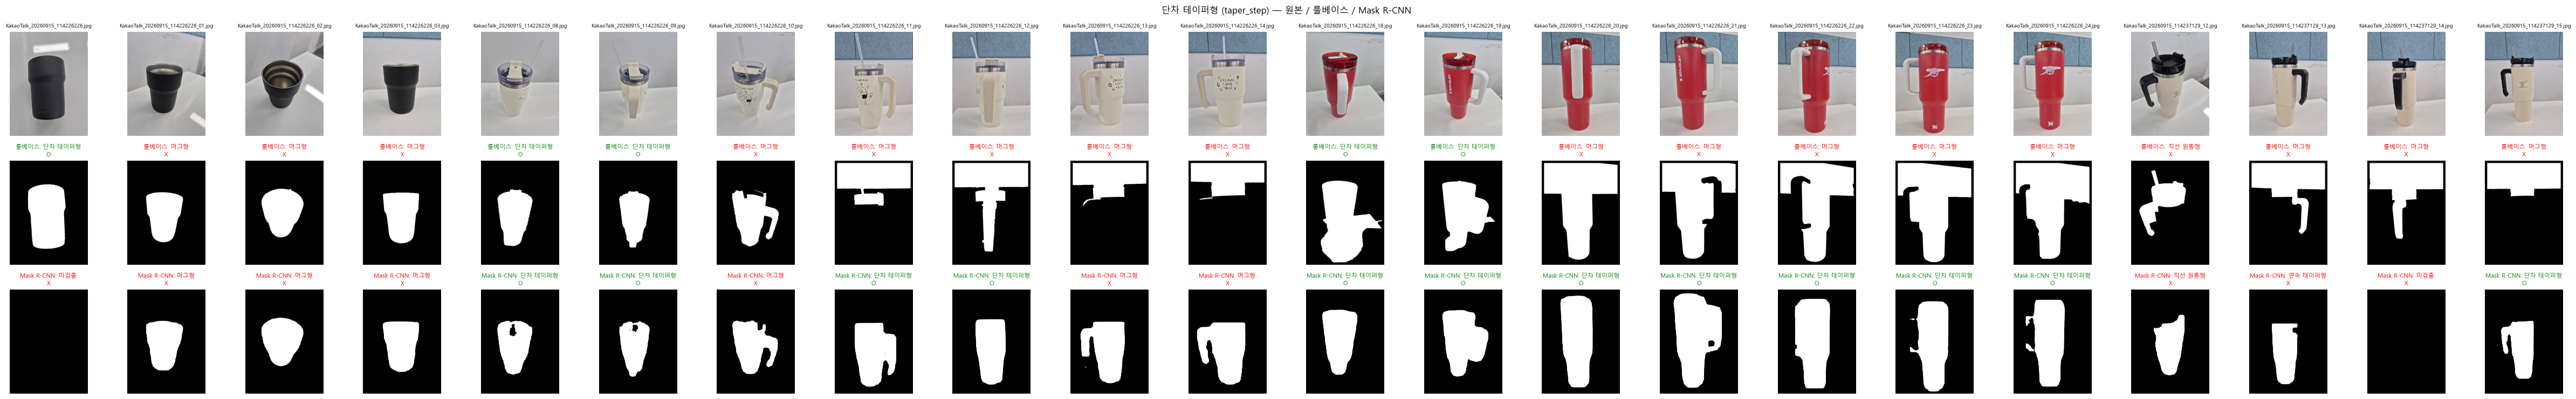

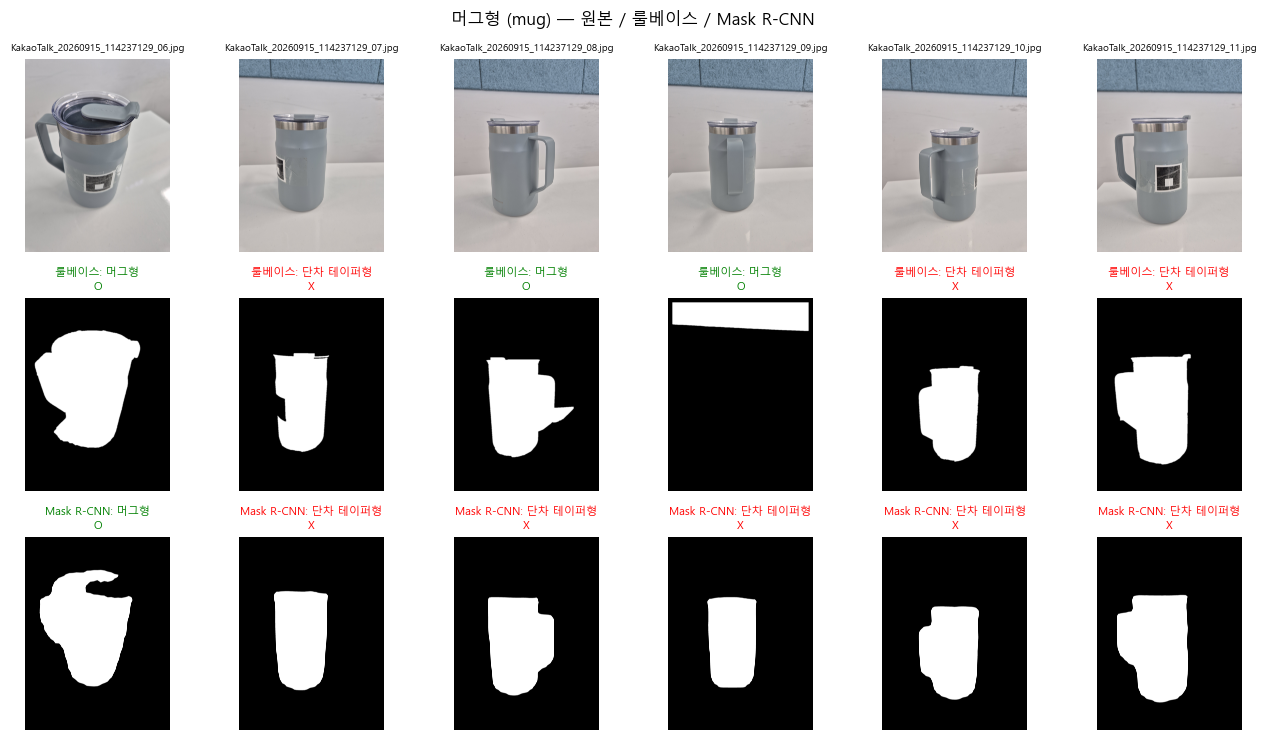

In [2]:
all_results = []
rule_times, mrcnn_times = [], []

for cls in CLASSES:
    paths = test_paths[cls]
    n = len(paths)
    if n == 0:
        continue
    fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 7.5))
    if n == 1:
        axes = axes.reshape(3, 1)

    for i, path in enumerate(paths):
        name = os.path.basename(path)
        image = imread_unicode(path)

        t0 = time.time()
        rule_mask = get_mask(image)
        rule_times.append(time.time() - t0)
        rule_result = safe_classify(rule_mask)

        t0 = time.time()
        mrcnn_mask = get_mask_maskrcnn(image, mrcnn_model, device)
        mrcnn_times.append(time.time() - t0)
        mrcnn_result = safe_classify(mrcnn_mask)

        rule_pred, mrcnn_pred = rule_result["shape"], mrcnn_result["shape"]
        rule_match, mrcnn_match = rule_pred == cls, mrcnn_pred == cls

        axes[0, i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(name, fontsize=7)
        axes[0, i].axis("off")

        axes[1, i].imshow(rule_mask, cmap="gray")
        rl = SHAPE_LABELS_KO.get(rule_pred, rule_pred)
        axes[1, i].set_title(f"룰베이스: {rl}\n{'O' if rule_match else 'X'}", fontsize=8,
                              color=("green" if rule_match else "red"))
        axes[1, i].axis("off")

        axes[2, i].imshow(mrcnn_mask if mrcnn_mask is not None else np.zeros_like(rule_mask), cmap="gray")
        ml = SHAPE_LABELS_KO.get(mrcnn_pred, mrcnn_pred)
        axes[2, i].set_title(f"Mask R-CNN: {ml}\n{'O' if mrcnn_match else 'X'}", fontsize=8,
                              color=("green" if mrcnn_match else "red"))
        axes[2, i].axis("off")

        all_results.append({
            "folder_class": cls, "file": name,
            "rule_pred": rule_pred, "rule_match": rule_match,
            "mrcnn_pred": mrcnn_pred, "mrcnn_match": mrcnn_match,
        })

    fig.suptitle(f"{SHAPE_LABELS_KO[cls]} ({cls}) — 원본 / 룰베이스 / Mask R-CNN", fontsize=12)
    plt.tight_layout()
    plt.show()

## 정확도 비교 (진짜 Test 세트 기준 — 라벨 확실함, raw2와 달리 검증된 값)

In [3]:
header = f"{'클래스':14s} {'표본':>6s} {'룰베이스':>12s} {'Mask R-CNN':>12s}"
print(header)
print("-" * len(header))
for cls in CLASSES:
    cls_results = [r for r in all_results if r["folder_class"] == cls]
    total = len(cls_results)
    if total == 0:
        continue
    rm = sum(r["rule_match"] for r in cls_results)
    mm = sum(r["mrcnn_match"] for r in cls_results)
    print(f"{cls:14s} {total:6d} {rm}/{total} ({rm/total*100:4.0f}%) {mm}/{total} ({mm/total*100:4.0f}%)")

total = len(all_results)
rm = sum(r["rule_match"] for r in all_results)
mm = sum(r["mrcnn_match"] for r in all_results)
print("-" * len(header))
print(f"{'합계':14s} {total:6d} {rm}/{total} ({rm/total*100:4.0f}%) {mm}/{total} ({mm/total*100:4.0f}%)")

클래스                표본         룰베이스   Mask R-CNN
-----------------------------------------------
straight           18 1/18 (   6%) 2/18 (  11%)
taper_smooth       10 1/10 (  10%) 7/10 (  70%)
taper_step         22 5/22 (  23%) 12/22 (  55%)
mug                 6 3/6 (  50%) 1/6 (  17%)
-----------------------------------------------
합계                 56 10/56 (  18%) 22/56 (  39%)


## 혼동 분포

In [4]:
for name, key in (("룰베이스", "rule_pred"), ("Mask R-CNN", "mrcnn_pred")):
    print(f"=== {name} ===")
    for cls in CLASSES:
        cls_results = [r for r in all_results if r["folder_class"] == cls]
        if not cls_results:
            continue
        counts = Counter(r[key] for r in cls_results)
        breakdown = ", ".join(f"{SHAPE_LABELS_KO.get(k, k)}({k})={v}" for k, v in counts.most_common())
        print(f"  {cls:14s}: {breakdown}")
    print()

=== 룰베이스 ===
  straight      : 머그형(mug)=12, 연속 테이퍼형(taper_smooth)=4, 단차 테이퍼형(taper_step)=1, 직선 원통형(straight)=1
  taper_smooth  : 머그형(mug)=6, 단차 테이퍼형(taper_step)=2, 직선 원통형(straight)=1, 연속 테이퍼형(taper_smooth)=1
  taper_step    : 머그형(mug)=16, 단차 테이퍼형(taper_step)=5, 직선 원통형(straight)=1
  mug           : 머그형(mug)=3, 단차 테이퍼형(taper_step)=3

=== Mask R-CNN ===
  straight      : 단차 테이퍼형(taper_step)=8, 연속 테이퍼형(taper_smooth)=5, 머그형(mug)=3, 직선 원통형(straight)=2
  taper_smooth  : 연속 테이퍼형(taper_smooth)=7, 머그형(mug)=2, 단차 테이퍼형(taper_step)=1
  taper_step    : 단차 테이퍼형(taper_step)=12, 머그형(mug)=6, 미검출(미검출)=2, 직선 원통형(straight)=1, 연속 테이퍼형(taper_smooth)=1
  mug           : 단차 테이퍼형(taper_step)=5, 머그형(mug)=1



## 추론 속도

In [5]:
print(f"룰베이스 get_mask()      평균 {np.mean(rule_times)*1000:6.1f}ms/장")
print(f"Mask R-CNN ({device})   평균 {np.mean(mrcnn_times)*1000:6.1f}ms/장")

룰베이스 get_mask()      평균 5912.9ms/장
Mask R-CNN (cuda)   평균  918.7ms/장


**해석**: `data/raw2`(크롤링/수집)와 정확도가 다르게 나온다면 domain shift가 실제로 존재한다는 뜻 — 정상적인 현상이다(README/CLAUDE.md 참고). `data/test/`는 표본이 작고(클래스당 6~22장) 클래스별 불균형이 있어(mug 6장뿐) 통계적으로 약하다는 점도 감안할 것.